## [Условие](https://drive.google.com/drive/folders/1dmjOfAxLsxznG1Efq0vvU12DJRFeG1j8)

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [68]:
df = pd.read_csv('../data/avianHabitat.csv')
df.head(5)

,Site,Observer,Subpoint,VOR,PDB,DBHt,PW,WHt,PE,EHt,PA,AHt,PH,HHt,PL,LHt,PB
0,BunkerHill27,RA,1,6.0,3,5.2,0,0.0,4,2.9,0,0.0,4,3.0,0,0.0,0
1,BunkerHill27,RA,2,4.5,2,3.1,3,4.7,3,4.1,0,0.0,3,3.5,2,1.0,0
2,BunkerHill27,RA,3,2.0,4,5.5,1,5.8,3,3.9,0,0.0,3,7.5,0,0.0,0
3,BunkerHill27,RA,4,2.5,3,6.2,0,0.0,3,4.0,0,0.0,4,5.0,0,0.0,0
4,BunkerHill27,RA,5,4.0,4,5.4,0,0.0,3,3.5,0,0.0,4,3.7,0,0.0,0


In [80]:
df['WHt'].value_counts().sort_index()

WHt
0.00     423
0.05       2
0.10      15
0.20      28
0.30      40
        ... 
18.00      1
18.40      1
18.50      1
22.00      1
24.50      1
Name: count, Length: 80, dtype: int64

Удалим нули (не ивы)

In [70]:
my_df = df[df['WHt'] != 0][['WHt']]
my_df

,WHt
1,4.7
2,5.8
6,6.3
7,4.1
8,5.7
...,...
1065,1.0
1066,1.3
1067,10.2
1068,10.1


## Статистики

In [71]:
maximum = my_df.max()
print(f'Максимальное значение: {maximum}')

minimum = my_df.min()
print(f'Минимальное значение: {minimum}')

range = maximum - minimum
print(f'Размах: {range}')

average = my_df.mean()
print(f'Среднее значение: {average}')

median = my_df.median()
print(f'Медианное значение: {median}')

mode = my_df.mode()
print(f'Мода: {mode}')

variance = my_df.var()
print(f'Дисперсия: {variance}')

std = my_df.std()
print(f'Стандартное отклонение: {std}')

print("Q1:", my_df.quantile(0.25))
print("Q3:", my_df.quantile(0.75))
print("IQR:", my_df.quantile(0.75) - my_df.quantile(0.25))
print("Асимметрия:", my_df.skew())
print("Эксцесс:", my_df.kurt())

Максимальное значение: WHt    24.5
dtype: float64
Минимальное значение: WHt    0.05
dtype: float64
Размах: WHt    24.45
dtype: float64
Среднее значение: WHt    1.698145
dtype: float64
Медианное значение: WHt    0.9
dtype: float64
Мода:    WHt
0  0.6
1  0.7
Дисперсия: WHt    7.147419
dtype: float64
Стандартное отклонение: WHt    2.673466
dtype: float64
Q1: WHt    0.5
Name: 0.25, dtype: float64
Q3: WHt    1.7
Name: 0.75, dtype: float64
IQR: WHt    1.2
dtype: float64
Асимметрия: WHt    4.588145
dtype: float64
Эксцесс: WHt    25.79095
dtype: float64


Получим высоты травяных растений

In [81]:
other_df = df[df['EHt'] != 0][['EHt']]
other_df.value_counts().sort_index()

EHt
0.1     6
0.2    34
0.3    50
0.4    59
0.5    68
0.6    49
0.7    50
0.8    61
0.9    51
1.0    52
1.1    48
1.2    42
1.3    39
1.4    46
1.5    32
1.6    22
1.7    24
1.8    19
1.9    13
2.0    17
2.1     9
2.2    12
2.3     7
2.4    10
2.5     2
2.6     9
2.7     9
2.8     5
2.9     5
3.0     4
3.1     3
3.2     3
3.3     2
3.4     1
3.5     2
3.7     3
3.8     2
3.9     1
4.0     4
4.1     2
4.2     3
4.3     2
4.5     1
4.8     1
4.9     1
5.2     1
5.3     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Травяные растения')

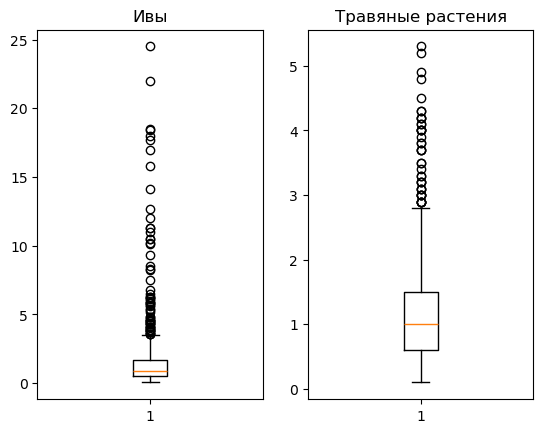

In [84]:
fig, ax = plt.subplots(1, 2)

ax[0].boxplot(my_df)
ax[0].set_title('Ивы')
ax[1].boxplot(other_df)
ax[1].set_title('Травяные растения')

У травы меньше выбросов

## Эмпирическая функция распределения

In [74]:
# xi = уникальные значения в выборке
# ni / n где ni -- число значений < xi
n = len(my_df)
x = sorted(np.unique(my_df))
y = pd.Series([len(my_df[my_df['WHt'] < xi]) / n for xi in x])
y

0     0.000000
1     0.003091
2     0.026275
3     0.069552
4     0.131376
        ...   
74    0.992272
75    0.993818
76    0.995363
77    0.996909
78    0.998454
Length: 79, dtype: float64

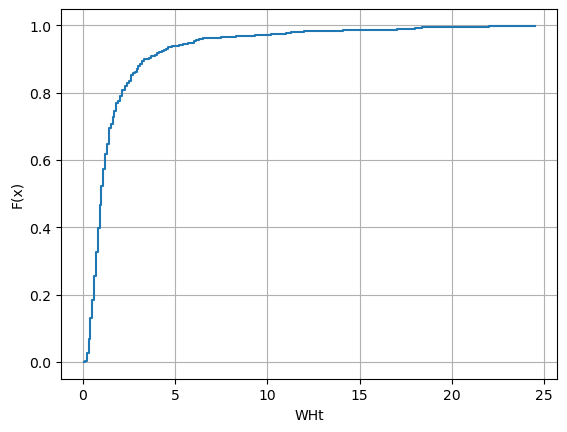

In [75]:
plt.step(x, y, where='post')
plt.xlabel('WHt')
plt.ylabel('F(x)')
plt.grid()
plt.show()

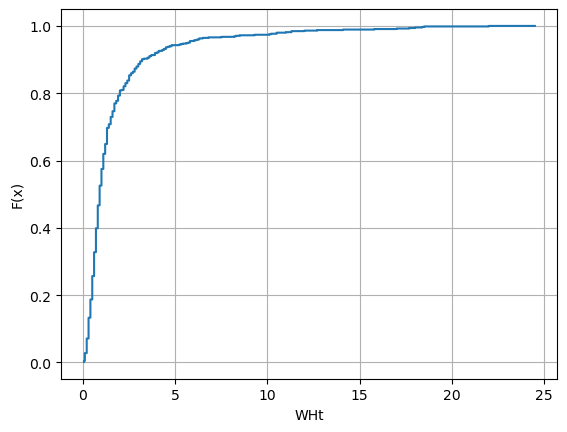

In [76]:
from statsmodels.distributions.empirical_distribution import ECDF

x = my_df["WHt"]

ecdf = ECDF(x)

plt.step(ecdf.x, ecdf.y)
plt.xlabel("WHt")
plt.ylabel("F(x)")
plt.grid()
plt.show()

x - all values in a sample
bins = k = 1,233 + lgn

In [77]:
k = int(np.ceil(1 + 3.322 * np.log(n)))
min_val = 0
max_val = my_df['WHt'].max()

bins = np.linspace(min_val, max_val, k + 1)
h = bins[1] - bins[0]

result = pd.cut(my_df['WHt'], bins=bins)
counts = result.value_counts().sort_index()
counts

WHt
(0.0, 1.065]        371
(1.065, 2.13]       152
(2.13, 3.196]        55
(3.196, 4.261]       20
(4.261, 5.326]       13
(5.326, 6.391]       11
(6.391, 7.457]        2
(7.457, 8.522]        4
(8.522, 9.587]        1
(9.587, 10.652]       4
(10.652, 11.717]      3
(11.717, 12.783]      2
(12.783, 13.848]      0
(13.848, 14.913]      1
(14.913, 15.978]      1
(15.978, 17.043]      1
(17.043, 18.109]      2
(18.109, 19.174]      2
(19.174, 20.239]      0
(20.239, 21.304]      0
(21.304, 22.37]       1
(22.37, 23.435]       0
(23.435, 24.5]        1
Name: count, dtype: int64

## Гистограмма вероятностей

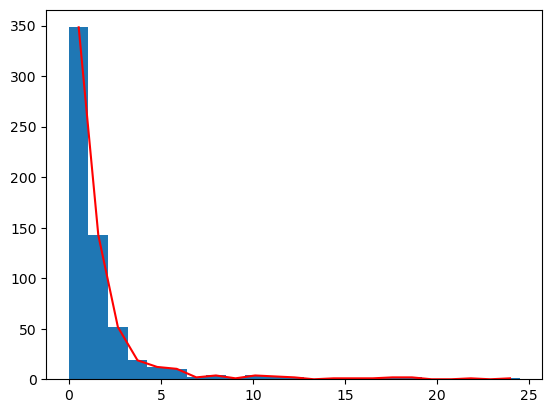

In [78]:
counts = counts / h
centers = (bins[:-1] + bins[1:]) / 2

width = bins[1] - bins[0]

plt.bar(centers, counts, width=width)
plt.plot(centers, counts, color='red')

## QQ-plot (сравнение со стандартным норм. распределением)

((array([-3.06987241, -2.79450057, -2.64012922, -2.53090427, -2.44547029,
         -2.37485629, -2.31441022, -2.2613971 , -2.21406765, -2.17123288,
         -2.13204655, -2.09588417, -2.06227129, -2.03083868, -2.00129314,
         -1.97339782, -1.94695856, -1.92181412, -1.89782911, -1.87488864,
         -1.85289443, -1.83176165, -1.81141661, -1.79179485, -1.77283965,
         -1.75450083, -1.73673376, -1.7194986 , -1.70275958, -1.6864845 ,
         -1.67064426, -1.65521245, -1.64016503, -1.62548007, -1.61113752,
         -1.59711892, -1.58340736, -1.56998718, -1.55684394, -1.54396427,
         -1.53133574, -1.51894682, -1.50678673, -1.49484546, -1.48311362,
         -1.47158243, -1.46024366, -1.44908958, -1.43811293, -1.42730687,
         -1.41666495, -1.4061811 , -1.39584956, -1.3856649 , -1.37562198,
         -1.36571592, -1.3559421 , -1.34629611, -1.33677379, -1.32737116,
         -1.31808445, -1.30891003, -1.29984448, -1.29088452, -1.28202701,
         -1.27326896, -1.2646075 , -1.

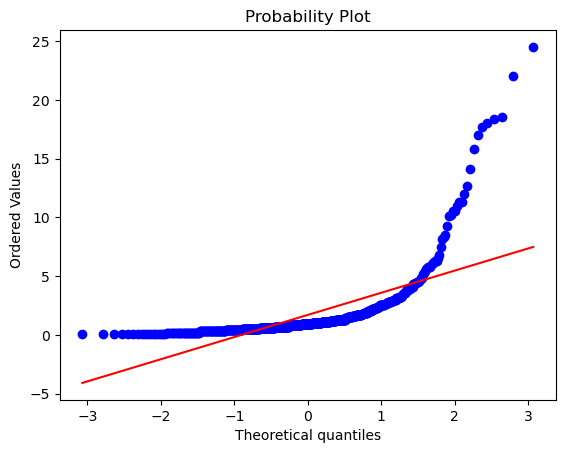

In [79]:
stats.probplot(my_df['WHt'], dist="norm", plot=plt)